<a href="https://colab.research.google.com/github/rajanani6767/ML/blob/main/task6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Sample
   study_hours  attendance  assignment_score  exam_score  pass
0     4.370861   62.067269         50.136104   62.159593     1
1     9.556429   81.254185         56.715420   88.589000     1
2     7.587945   81.625405         50.620629   87.295736     1
3     6.387926   85.497196         45.322152   74.793141     1
4     2.404168   89.043653         47.238152   55.015581     1

Dataset Shape: (300, 5)

Summary Statistics
       study_hours  attendance  assignment_score  exam_score        pass
count   300.000000  300.000000        300.000000  300.000000  300.000000
mean      5.456841   80.433260         68.265337   79.093794    0.953333
std       2.649065   12.103614         17.005649   15.691401    0.211276
min       1.045554   60.433506         40.277921   39.172585    0.000000
25%       3.151727   69.984597         52.585992   68.996204    1.000000
50%       5.605460   80.868111         67.171851   79.599882    1.000000
75%       7.811737   90.933681         83.019298   

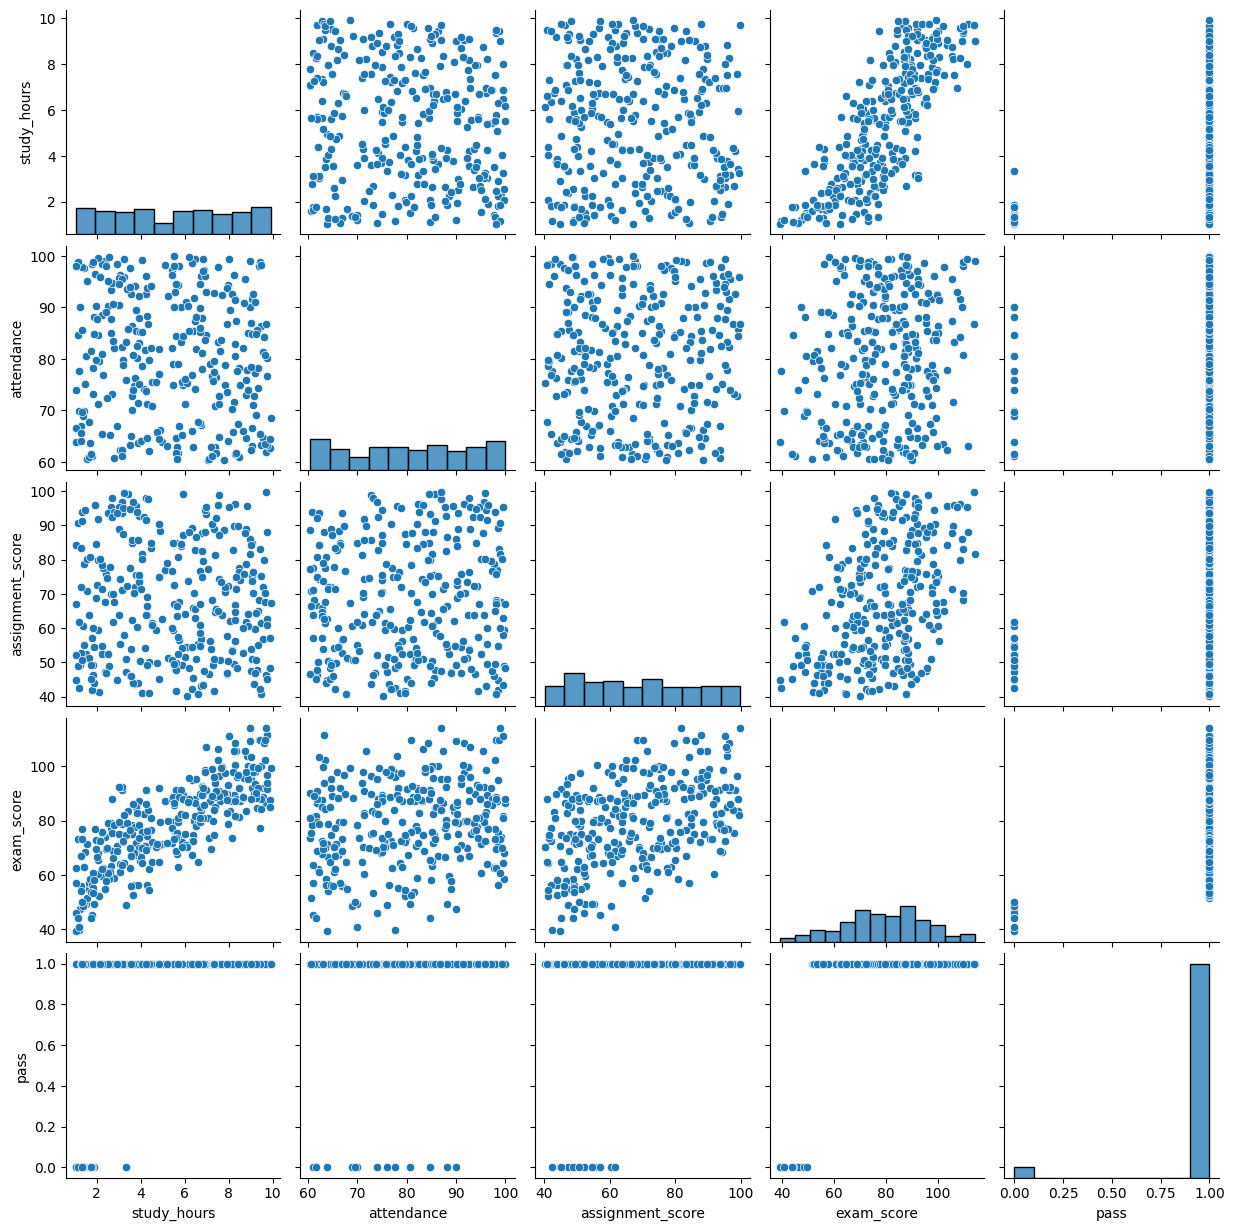


===== Simple Linear Regression =====
Coefficient: 4.699498432250064
Intercept: 53.84998720949848
Mean Squared Error: 67.59368848034623
R-Squared: 0.6796756703090112


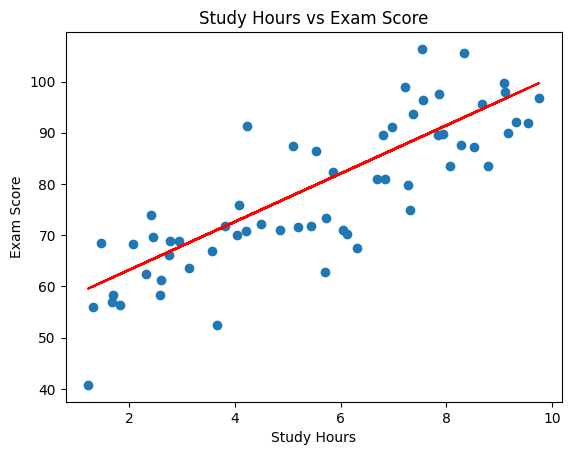


===== Multiple Linear Regression =====
Coefficients: [5.00327099 0.31631407 0.42457764]
Intercept: -2.2388680046853864
MSE: 28.316568139263456
R-Squared: 0.8658086884695434

===== Multicollinearity Check (VIF) =====
            Feature        VIF
0       study_hours   4.649397
1        attendance  15.316842
2  assignment_score  13.681131

===== Logistic Regression Results =====
Accuracy: 0.9666666666666667
Precision: 0.9830508474576272
Recall: 0.9830508474576272
F1 Score: 0.9830508474576272
ROC-AUC: 0.9830508474576272

Confusion Matrix
[[ 0  1]
 [ 1 58]]

===== Logit Equation =====
log(p/(1-p)) = -14.357162166286974 + 1.699591835960611 *StudyHours + 0.06897765744159554 *Attendance + 0.12250055181520768 *AssignmentScore


In [1]:
# ==========================================
# Import Libraries
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# ==========================================
# Create Large Student Dataset
# ==========================================

np.random.seed(42)

n = 300

study_hours = np.random.uniform(1,10,n)
attendance = np.random.uniform(60,100,n)
assignment = np.random.uniform(40,100,n)

# exam score formula
exam_score = (5*study_hours +
              0.3*attendance +
              0.4*assignment +
              np.random.normal(0,5,n))

data = pd.DataFrame({
    "study_hours":study_hours,
    "attendance":attendance,
    "assignment_score":assignment,
    "exam_score":exam_score
})

# pass fail column
data["pass"] = (data["exam_score"] >= 50).astype(int)

print("Dataset Sample")
print(data.head())

print("\nDataset Shape:",data.shape)

# ==========================================
# EDA
# ==========================================

print("\nSummary Statistics")
print(data.describe())

print("\nCorrelation Matrix")
print(data.corr())

sns.pairplot(data)
plt.show()

# ==========================================
# Simple Linear Regression
# ==========================================

X = data[["study_hours"]]
y = data["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(
X,y,test_size=0.2,random_state=42)

model = LinearRegression()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("\n===== Simple Linear Regression =====")
print("Coefficient:",model.coef_[0])
print("Intercept:",model.intercept_)

print("Mean Squared Error:",mse)
print("R-Squared:",r2)

# Plot regression
plt.scatter(X_test,y_test)
plt.plot(X_test,y_pred,color="red")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.show()

# ==========================================
# Multiple Linear Regression
# ==========================================

X_multi = data[["study_hours","attendance","assignment_score"]]
y_multi = data["exam_score"]

X_train,X_test,y_train,y_test = train_test_split(
X_multi,y_multi,test_size=0.2,random_state=42)

multi_model = LinearRegression()

multi_model.fit(X_train,y_train)

y_pred_multi = multi_model.predict(X_test)

mse_multi = mean_squared_error(y_test,y_pred_multi)
r2_multi = r2_score(y_test,y_pred_multi)

print("\n===== Multiple Linear Regression =====")

print("Coefficients:",multi_model.coef_)
print("Intercept:",multi_model.intercept_)

print("MSE:",mse_multi)
print("R-Squared:",r2_multi)

# ==========================================
# Multicollinearity Check (VIF)
# ==========================================

print("\n===== Multicollinearity Check (VIF) =====")

X_vif = data[["study_hours","attendance","assignment_score"]]

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values,i)
              for i in range(X_vif.shape[1])]

print(vif)

# ==========================================
# Logistic Regression (Pass / Fail)
# ==========================================

X_log = data[["study_hours","attendance","assignment_score"]]
y_log = data["pass"]

X_train,X_test,y_train,y_test = train_test_split(
X_log,y_log,test_size=0.2,random_state=42)

log_model = LogisticRegression()

log_model.fit(X_train,y_train)

y_pred = log_model.predict(X_test)

# probabilities
y_prob = log_model.predict_proba(X_test)[:,1]

# ==========================================
# Logistic Evaluation
# ==========================================

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_prob)
cm = confusion_matrix(y_test,y_pred)

print("\n===== Logistic Regression Results =====")

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("ROC-AUC:",roc_auc)

print("\nConfusion Matrix")
print(cm)

# ==========================================
# Logit Equation
# ==========================================

print("\n===== Logit Equation =====")

coef = log_model.coef_[0]
intercept = log_model.intercept_[0]

print("log(p/(1-p)) =",
      intercept,
      "+",coef[0],"*StudyHours",
      "+",coef[1],"*Attendance",
      "+",coef[2],"*AssignmentScore")